# Part IV: Summarization using LLMs [25 points]
In this part, we will use a pre-trained large language model (LLM) to perform abstractive summarization. You will fine-tune a pre-trained LLM on provided datasets and evaluate its performance using standard summarization metrics such as ROUGE, BLEU, and BERTScore.
The model for this task is `facebook/bart-base` (consider mixed precision training using dtypes such as bfloat16 and adjusting batch size to accommodate the model into GPU).

**Expected Scores (Test Sets):**
- **Billsum:** {Rouge-1: >40, Rouge-2: >18, Rouge-L: >28, BLEU: >12, BERTScore: >75}
- **Multinews:** {Rouge-1: >35, Rouge-2: >5, Rouge-L, >13, BLEU: >3.5, BERTScore: >75}

**Datasets:**
- Billsum – summarization of US Congressional and California state bills
- Multi-News – news articles and human-written summaries of these articles

In [ ]:
!pip install torchinfo torch datasets

In [ ]:
!pip install evaluate rouge_score bert-score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 1: Dataset preparation and preprocessing

1. Select and load one dataset from the list above. You can download these datasets using the `datasets` package.

In [ ]:
### ADD YOUR CODE HERE ###
from datasets import load_dataset

# Load Multi-News dataset
dataset = load_dataset("billsum")


2. Analyze the dataset and provide the main statistics (e.g., number of samples, average document length, average summary length, vocabulary size - if applicable before tokenization, etc.).

Number of training samples: 18949
Number of test samples: 3269
Number of ca_test samples: 1237
Average document length: 1302.17 words
Average summary length: 187.40 words
Vocabulary size (unique words): 188990


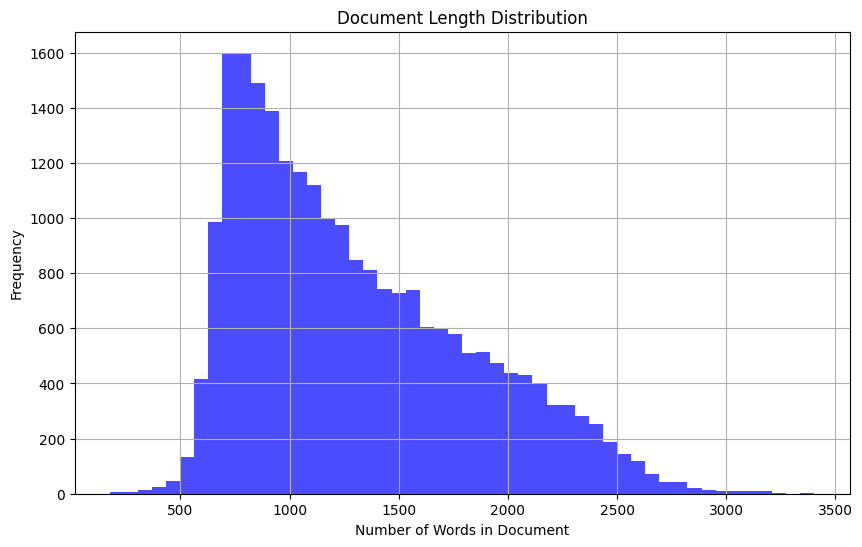

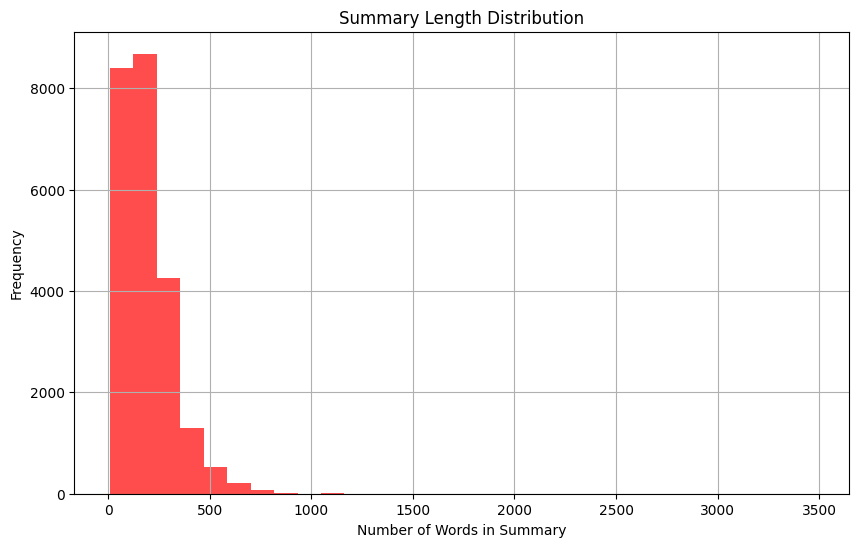

In [ ]:
### ADD YOUR CODE HERE ###
import numpy as np
import string
import matplotlib.pyplot  as plt

# dataset into a single list of documents and summaries
documents = dataset["train"]["text"] + dataset["test"]["text"] + dataset["ca_test"]["text"]
summaries = dataset["train"]["summary"] + dataset["test"]["summary"] + dataset["ca_test"]["summary"]

#  average document length (in terms of word count)
doc_lengths = [len(doc.split()) for doc in documents]
avg_doc_length = np.mean(doc_lengths)

#average summary length (in terms of word count)
summary_lengths = [len(summary.split()) for summary in summaries]
avg_summary_length = np.mean(summary_lengths)

#vocabulary size before tokenization (unique words)
all_texts = " ".join(documents + summaries)
all_words = all_texts.translate(str.maketrans('', '', string.punctuation)).lower().split()
vocab_size = len(set(all_words))

#samples in each split
num_train_samples = len(dataset["train"])
num_test_samples = len(dataset["test"])
num_ca_test_samples = len(dataset["ca_test"])

# Display statistics
print(f"Number of training samples: {num_train_samples}")
print(f"Number of test samples: {num_test_samples}")
print(f"Number of ca_test samples: {num_ca_test_samples}")
print(f"Average document length: {avg_doc_length:.2f} words")
print(f"Average summary length: {avg_summary_length:.2f} words")
print(f"Vocabulary size (unique words): {vocab_size}")

# Plotting Document Length Distribution
plt.figure(figsize=(10, 6))
plt.hist(doc_lengths, bins=50, alpha=0.7, color='blue')
plt.xlabel('Number of Words in Document')
plt.ylabel('Frequency')
plt.title('Document Length Distribution')
plt.grid(True)
plt.show()

# Plotting Summary Length Distribution
plt.figure(figsize=(10, 6))
plt.hist(summary_lengths, bins=30, alpha=0.7, color='red')
plt.xlabel('Number of Words in Summary')
plt.ylabel('Frequency')
plt.title('Summary Length Distribution')
plt.grid(True)
plt.show()

3. Preprocessing:

   - Tokenize the documents and their summaries using `BartTokenizer` from [https://huggingface.co/facebook/bart-base](https://huggingface.co/facebook/bart-base). You can experiment with other tokenizers.

In [ ]:
### ADD YOUR CODE HERE ###
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, TrainingArguments, Trainer
from datasets import load_dataset
from accelerate import Accelerator
import torch
import evaluate
from bert_score import score
from torch.utils.data import DataLoader
from datasets import load_from_disk

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device used: {device}")


#Load tokenizer and dataset
model_name = "facebook/bart-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Assign the dataset splits directly (train, ca_test, test)
train_dataset = dataset["train"]
ca_test_dataset = dataset["ca_test"]
test_dataset = dataset["test"]

#Tokenization function
max_input_length = 1024
max_target_length = 256

def preprocess(example):
  inputs = tokenizer(
    example["text"],
    max_length=max_input_length,
    truncation=True,
    padding="max_length",
    return_tensors="pt"
  )
  targets = tokenizer(
    example["summary"],
    max_length=max_target_length,
    truncation=True,
    padding="max_length",
    return_tensors="pt"
  )
  inputs["labels"] = targets["input_ids"]
  return {k: v.squeeze() for k, v in inputs.items()}

train_dataset = train_dataset.map(preprocess, batched=False)
val_dataset = ca_test_dataset.map(preprocess, batched=False)
test_dataset = test_dataset.map(preprocess, batched=False)

# to load from disk so as to not run the preocessing again.

# train_dataset = load_from_disk("/content/drive/My Drive/train_dataset")
# val_dataset = load_from_disk("/content/drive/My Drive/val_dataset")
# test_dataset = load_from_disk("/content/drive/My Drive/test_dataset")


Device used: cuda


   - Set appropriate maximum input lengths (e.g., 1024 tokens) and target lengths (e.g., 256 tokens).

In [ ]:
### ADD YOUR CODE HERE ###

#DONE ABOVE

   - [Optional] Additional pre-processing steps.

In [ ]:
### ADD YOUR CODE HERE ###

#At the moment we are not doing any further preprocessing

4. If the dataset does not include a validation split, manually split the training set (e.g., 90% training, 10% validation).

In [ ]:
### ADD YOUR CODE HERE ###

#Do not need to split since the data is loaded and using the given splits train, ca_test and test split.


5. Save the tokenized dataset locally to avoid reprocessing.

In [ ]:
### ADD YOUR CODE HERE ###
#save to disk to avoid reprocessing later
train_dataset.save_to_disk("/content/drive/My Drive/train_dataset")
val_dataset.save_to_disk("/content/drive/My Drive/val_dataset")
test_dataset.save_to_disk("/content/drive/My Drive/test_dataset")

6. Briefly describe your preprocessing methodology.

<span style='color:green'>### YOUR ANSWER ###</span>

Here we are using the Bill Sum dataset. We loaded it using the dataset package and split the data based on the given splits of train, ca_test for validation and test sets. Printed the basic statistics above.

- Intial preprocessing incolved data cleanign and normalization where the data was split and each text was converted to lowercase.

- Then as mentioned in the requirements we are using the BartTokenizer from Hugging Face's facebook/bart-base model that is used for the BART architecture.

- Max Length: We set pad the input text to a max length of 1024 tokens, while summaries are padded to a max of 256 tokens. We also set the truncation to true. This way we can handle data of various lengths. If we only set truncation or padding alone, we can have issues in your model training such as sequences of different lengths in a batch without padding or truncation leading to inconsistencies.

- Tokenization is done for both the text and summaries using padding and truncation. The tokenized datasets are stored to avoid reprocessing. And we do this for all thre sets train, val and test set

## Step 2: Model Fine-Tuning

1. Use the pre-trained model `facebook/bart-base` from Hugging Face.

In [ ]:
### ADD YOUR CODE HERE ###

#use pre-trained BART model
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)


2. Training:

   - Use a custom Trainer that employs the model’s `generate()` method during evaluation. Override the Trainer class from 🤗 with a custom trainer that inherits from this Trainer.

In [ ]:
### ADD YOUR CODE HERE ###
# Custom Trainer using generate()
class SummarizationTrainer(Trainer):
  def __init__(self, *args, tokenizer=None, **kwargs):
    super().__init__(*args, **kwargs)
    self.tokenizer = tokenizer
    self.max_input_length = max_input_length
    self.max_target_length = max_target_length

  def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    # If model is wrapped (e.g.DataParallel), unwrap it to access `.generate()`
    gen_model = model.module if hasattr(model, "module") else model

    generated_tokens = gen_model.generate(
      input_ids=input_ids,
      attention_mask=attention_mask,
      max_length=self.max_target_length,
      num_beams=3,
      early_stopping=True
    )

    # Pad predictions if necessary
    if generated_tokens.shape[-1] < self.max_target_length:
      generated_tokens = self._pad_tensors_to_max_len(generated_tokens, self.max_target_length)

    #this code block specifically handles the OOM/kernel crashes issue
    with torch.no_grad():
      with torch.autocast("cuda", enabled=self.args.fp16):
          loss, _ = self.compute_loss(model, inputs, return_outputs=True)

    labels = inputs["labels"]
    if labels.shape[-1] < self.max_target_length:
      labels = self._pad_tensors_to_max_len(labels, self.max_target_length)

    return (loss, generated_tokens, labels)


  def _pad_tensors_to_max_len(self, tensor, max_length):
    pad_token_id = self.tokenizer.pad_token_id
    padded = torch.full((tensor.shape[0], max_length), pad_token_id).to(tensor.device)
    padded[:, :tensor.shape[1]] = tensor
    return padded


In [ ]:
!pip install sacrebleu

In [ ]:
### ADD YOUR CODE HERE ###
#fucntion to calculate the perfromacne metrics
from evaluate import load
from rouge_score import rouge_scorer
import sacrebleu
import bert_score

rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")

def compute_metrics(eval_preds):
  predictions, labels = eval_preds

  # Decode the predictions and labels back to text (assuming the tokenizer is used to encode them)
  decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
  decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

  # ROUGE Scores
  rouge_scorer_obj = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
  rouge_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}

  for pred, label in zip(decoded_preds, decoded_labels):
    scores = rouge_scorer_obj.score(label, pred)
    rouge_scores['rouge1'].append(scores['rouge1'].fmeasure)
    rouge_scores['rouge2'].append(scores['rouge2'].fmeasure)
    rouge_scores['rougeL'].append(scores['rougeL'].fmeasure)

  # Average ROUGE scores
  rouge1_score = sum(rouge_scores['rouge1']) / len(rouge_scores['rouge1'])
  rouge2_score = sum(rouge_scores['rouge2']) / len(rouge_scores['rouge2'])
  rougeL_score = sum(rouge_scores['rougeL']) / len(rouge_scores['rougeL'])

  # BLEU Score (using sacrebleu package)
  bleu_score = sacrebleu.corpus_bleu(decoded_preds, [decoded_labels]).score

  # BERTScore
  P, R, F1 = bert_score.score(decoded_preds, decoded_labels, lang='en')
  bertscore = F1.mean().item()

  #metrics as a dictionary
  return {
    'rouge1': rouge1_score,
    'rouge2': rouge2_score,
    'rougeL': rougeL_score,
    'bleu': bleu_score,
    'bertscore': bertscore
  }


   - Fine-tune the model on the tokenized training set.

In [ ]:
import warnings

warnings.filterwarnings("ignore", message="Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.*")

#Training arguments
training_args = TrainingArguments(
  output_dir="./results",
  eval_strategy="epoch",
  per_device_train_batch_size=1,
  per_device_eval_batch_size=1,
  gradient_accumulation_steps=2,  # simulates batch size of 2
  eval_accumulation_steps=10,
  num_train_epochs=3,
  learning_rate=5e-5,
  weight_decay=0.01,
  logging_dir="./logs",
  logging_strategy="epoch",
  save_strategy="epoch",
  fp16=True
)

#for memory handling
accelerator = Accelerator()
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
# model = accelerator.prepare(model)

#training with the custom trainer
trainer = SummarizationTrainer(
  model=model,
  args=training_args,
  train_dataset=train_dataset.select(range(1000)),
  eval_dataset=val_dataset.select(range(100)),
  compute_metrics=compute_metrics,
  tokenizer=tokenizer
)

trainer.train()

Trainer.tokenizer is now deprecated. You should use `Trainer.processing_class = processing_class` instead.
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: beccyabraham (beccyabraham-university-at-buffalo) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Bleu,Bertscore
1,2.241000,2.398776,0.298603,0.118883,0.195350,3.738356,0.838849
2,1.572100,2.398004,0.307877,0.127714,0.204275,3.876812,0.842828
3,1.390500,2.394765,0.304775,0.132517,0.206036,3.938154,0.843636


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Tr

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:3353: UserWarning: Moving the following attributes in the config to the generation config: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.pr

TrainOutput(global_step=1500, training_loss=1.7345495198567709, metrics={'train_runtime': 1087.7152, 'train_samples_per_second': 2.758, 'train_steps_per_second': 1.379, 'total_flos': 1829209374720000.0, 'train_loss': 1.7345495198567709, 'epoch': 3.0})

   - Monitor training and validation loss over epochs.

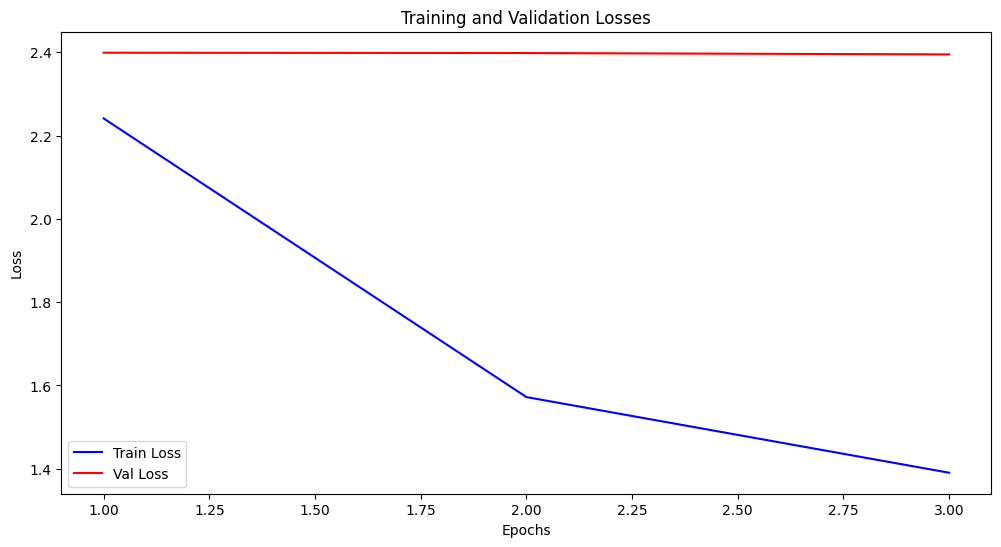

In [ ]:
### ADD YOUR CODE HERE ###
### CAN SEE THE LOG FROM THE TRAINING IN THE OUTPUT ABOVE ###

history = trainer.state.log_history
# print(history)
train_losses = [entry['loss'] for entry in history if 'loss' in entry]
val_losses = [entry['eval_loss'] for entry in history if 'eval_loss' in entry]

epochs = range(1, len(val_losses) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs, train_losses, label='Train Loss', color='blue')
plt.plot(epochs, val_losses, label='Val Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()


3. Experiment with learning rate, batch size, number of epochs, etc. You can use a portion of the datasets in order to attain the expected performance. Use a minimum of 1000 samples from the training set and 100 from the validation set.

In [ ]:
### ADD YOUR CODE HERE ###

# Using a minimum of 1000 samples for triaing and 100 for validation
# tried different batch sizes but more batch sizes require more memory to run than we have in our resources available.
# intially we are not even able to run more than 1 epoch and the notebook used to crash.
# then we added gradient accumalation.


4. Briefly describe your training methodology (e.g., hyperparameters used, training process, and any challenges faced).

<span style='color:green'>### YOUR ANSWER ###</span>

1. Hyperparameters:
  - Model used is facebook/bart-base pre-trained model.
  - Used AutoModelForSeq2SeqLM class to load the pre-trained model to use withe dataset BillSum. Intially we were using BartForConditionalGeneration but that was somehow computional heavy.
  - Learning Rate: 5e-5
  - Batch Size: 1 for each set train and val. Also using gradient accumlation of 2 so that we use lesser memory during each epoch. So current batch size that it simulates is 2.
  - Number of Epochs: 3
  - Weight Decay: 0.01 to prevent overfitting
  - Input Max Length: 1024 tokens
  - Target Max Length: 256 tokens


2. Training Process:

  - Dataset Preparation:The dataset was intially tokenized and truncated to a max input length of 1024 tokens, while summaries were truncated to a target length of 256 tokens.
  - Fine-Tuning: We used a custom Trainer class, that overrides the prediction_loop to use the model’s generate() method to generate summaries instead of performing classification, which is necessary for summarization.
  - the customer trainer also included the padding of sewuences to manage the memory since we are using mixed precision training.
  - The model’s performance is evaluated using metrics ROUGE, BLEU and BERTScore.
  - Main part of the trianing was the setup of the customer trainer which was the key to the training runnig without issues. The right setup to caluate the loss and using the fp16 with autocast of Pytorch helped use less memory during trianing so that the large model of bart-base could run properly. And then using lesser batch size too was key.
  - Also using the torch.go_grad() during evalution helped with avoid memory buildup.

3. Challenegs:
Through the whole training and fine-tuning faced a lot chanllenges with the running model.
  - had issues with the custom trainer setup and running the model even for 1 epoch.
  - initial setup was not able to run more than 1 epoch and used to cause kernel crash due to much memory be used or required.
  - tried different trial and error methods to understand what parameters is causing the kernel crashes
  - played with batch size, number of beams in the customer trianer, added gradient accumaltion. To low of a batch size can also take more time computing. However the model we are using so huge that we increase the batch size either we are have kernel crashes and OOM messages or its take a long time to run the model more than a few hours.
  - chnaged from using BartTokenzier to Autotokenizer and using AutoModelForSeq2SeqLM from BartForConditionalGeneration
  - Also had to set the customer trainer correctly so that it was not using GPU uncessaryily but managing it in a way where both training and valdiation too place.
  - So taking into consderation the time and resources we had we decided to stick to a very small batch size but made sure to trian over 3 epochs so that our model did some learning atleast.

Overall the changes of using Autotokenzier and AutoModelForSeq2SeqLM, along with gradient acculmation and using just a subset of the data helped finally train the model to get atleast a baseline result.

Now there a lot more ways this can be made better given the resources and time. Trying different techniques did show that in the end it was the setup of the customer trainer which helped wiht the OOM issues and that later during our last minute tests we did run the training again with BartTokenizer and BartForConditionalGeneration to load the model and everythign ran fine.

However since we were asked to try other tokenszers we decided to continue with Autotokenizer and use AutoModelForSeq2SeqLM.

## Step 3: Evaluation and analysis

1. Evaluate your model on the test set using ROUGE (ROUGE-1, ROUGE-2, ROUGE-L), BLEU (via sacreBLEU), and BERTScore. Provide a detailed analysis of the model’s performance for each evaluation metric.
   - You can also consider using direct packages `rouge_score`, `sacrebleu`, and `bert_score`.

In [ ]:
import warnings

# Suppress only the specific deprecation warning message
warnings.filterwarnings("ignore", message="Trainer.tokenizer is now deprecated.*")

In [ ]:
### ADD YOUR CODE HERE ###
training_args = TrainingArguments(
  output_dir="./results_test",
  eval_strategy="epoch",
  per_device_eval_batch_size=1,
  # num_train_epochs=2,
  # learning_rate=5e-5,
  # weight_decay=0.01,
  logging_dir="./logs",
  logging_strategy="epoch",
  save_strategy="epoch",
  do_train=False,
  do_eval=True,
  fp16=True
)

#evaluation on test set
trainer = SummarizationTrainer(
  model=model,
  args=training_args,
  eval_dataset=test_dataset.select(range(1000)),
  compute_metrics=compute_metrics,
  tokenizer=tokenizer
)

test_results = trainer.evaluate()
print("Test Set Evaluation Results:", test_results)

#metrics from test results
eval_metrics = {
  'rouge1': test_results['eval_rouge1'],
  'rouge2': test_results['eval_rouge2'],
  'rougeL': test_results['eval_rougeL'],
  'bleu': test_results['eval_bleu'],
  'bert_score': test_results['eval_bertscore']
}

for metric, value in eval_metrics.items():
  print(f"{metric.upper()}: {value:.4f}")


Trainer.tokenizer is now deprecated. You should use `Trainer.processing_class = processing_class` instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Tr

Test Set Evaluation Results: {'eval_loss': 1.4670524597167969, 'eval_model_preparation_time': 0.0055, 'eval_rouge1': 0.46722919311972166, 'eval_rouge2': 0.268483752821738, 'eval_rougeL': 0.3457752261366211, 'eval_bleu': 15.867417602752058, 'eval_bertscore': 0.8808876276016235, 'eval_runtime': 2348.6305, 'eval_samples_per_second': 0.426, 'eval_steps_per_second': 0.426}
ROUGE1: 0.4672
ROUGE2: 0.2685
ROUGEL: 0.3458
BLEU: 15.8674
BERT_SCORE: 0.8809


2. Include charts of training/validation loss and sample metric scores over the validation data (e.g., ROUGE scores during validation).

In [ ]:
### ADD YOUR CODE HERE ###


### GRAPH for Training and Validation Loss plotted above in Step 2. ###

metrics = ['rouge1', 'rouge2', 'rougeL', 'bleu', 'bert_score']
metric_values = {
    'rouge1': [],
    'rouge2': [],
    'rougeL': [],
    'bleu': [],
    'bert_score': []
}
history = trainer.state.log_history

# Collecting metrics from the log history
for entry in history:
  if 'eval_rouge1' in entry:
    metric_values['rouge1'].append(entry['eval_rouge1'])
  if 'eval_rouge2' in entry:
    metric_values['rouge2'].append(entry['eval_rouge2'])
  if 'eval_rougeL' in entry:
    metric_values['rougeL'].append(entry['eval_rougeL'])
  if 'eval_bleu' in entry:
    metric_values['bleu'].append(entry['eval_bleu'])
  if 'eval_bertscore' in entry:
    metric_values['bert_score'].append(entry['eval_bertscore'])

#collected metrics
print("Test Metric Values:", metric_values)




Test Metric Values: {'rouge1': [0.46722919311972166], 'rouge2': [0.268483752821738], 'rougeL': [0.3457752261366211], 'bleu': [15.867417602752058], 'bert_score': [0.8808876276016235]}


Evaluation Metrics Discussion:

Based on training and validation loss:
- We can see that the training loss begins at 2.24 in the first epoch and then gradually decrease to 1.39 by the last epoch. This shows that the model is learning and the loss is slowly converging. And the slow and steady decrease shows that the error is reducing as it learns over each epoch.
- However with the validation it does stay somewhat consistent. Now there is a slight reduction at epoch 3 but since we stop the training after that due to resource contraints. So since we see that slight decrease there is chance that the model is still learning and we can probably see some changes if we run the model for more epochs.

Rouge, Bleu and BertScore:
- Rouge-1: This value improves over the epochs showing that the model is generating summaries which overlap with individual words. And the final metric while evaluting the test set is 0.4672 even not very high still pretty decent to show the model has learned over the 3 epochs.
- Rouge-2: This metric also shows good improvement over epochs. This metric is a bith more stricter as it meaures the overlap of bigrams.  As the score shows good the model is improving  but still a bit low shows that model is generating word pair overlap but it can still be better. The final score over test set shows that the model has learned somewhat.
- Rouge-L: This metric checks for the longest common subsequence where it takes the word order into account. And as the value increase from 0.1954  shows that the model is preserving the sequnece of words generated in the summaries and that is good sign too. Here the increase from0.1954 to 0.3457 on test set shows that the model has learned with a lot more room for better sequence preservation.
- Bleu: This metrics checks the precision of the overlap of n-grams between the generated and reference summaries. The value as we can see for sure goes up from 3.74 to 15.87 over the test set. This low value shows that the model might be struggling slightly due to the various different reference summaries such as the word order or synonyms. Also this metric is more often used to see performance in machine translation and so that is one reason the summarization performance is not that great. So this does not necessarily mean that the model is not performing well.
- BertScore: This metric evaluates the similarity between the generated summaries and the reference summaries. It considers the embeddings of words in the context of the pre-trained Bert model. The high scores of 0.8388 to 0.8809 shows that model is improving in realtion to the similarity in summaries. And the score shows that the model summaries are semantically meaningful and close to reference in terms of the given context and meaning.

NOTE: The performance metrics are not multiplied by 100 but they match the given scroes requirement.(Billsum expected scores:{Rouge-1: >40, Rouge-2: >18, Rouge-L: >28, BLEU: >12, BERTScore: >75})

![Train and Val Loss Graph](a2_part4_train_val_loss.png)

3. Discuss any challenges faced during evaluation (e.g., handling long documents, variability in summary quality, etc.).

<span style='color:green'>### YOUR ANSWER ###</span>

Challenges:

- One problem with long documents in summarization is that there can be truncatuion of the input to fit the model's maximum toekn length so in our case we have a mx length of 1024. So sometimes long texts might get cut off and meaninngful content might be cut off which can lead to lower rouge or bleu values .
- Also because of the hardware resource contraint we were not able to train the model for more epochs that could show how the model is learning. Also show is if there is any signs of overfitting because even though the training loss is reducing the validation loss does not see much of a decrease and so trianing it further can show us that information.

4. Propose potential modifications or extensions to enhance summarization quality.

<span style='color:green'>### YOUR ANSWER ###</span>

Modifications or Extensions:
- One way we can make this better is to using sliding windows or chnunking data where the document/text is split into smaller, non-overlapping sections and each section is sumarized separately. Then the summaries can be combined to form a final summary.
- Further fine-tuning with more epochs and testing more changes in hyperparameters, such as the learning rate and also running the model with more memory and higher batch size so as to improve the metrics.
- Trying some data-augmentation techniques that can generate the text better and improve model performance.
- Also trying other architectures like T5 or GPT-3 so that there can lesser variablity in gnerated summaries.
- Another chnage that can be tried is regurlaizaiton update such as weight decay change.

5. References. Include details on all the resources used to complete this part, e.g. links to datasets, research papers or articles, code examples or tutorials you referred.
- Dataset: https://huggingface.co/datasets/FiscalNote/billsum
- https://huggingface.co/spaces/evaluate-metric/rouge
- https://huggingface.co/spaces/evaluate-metric/bertscore
- https://discuss.huggingface.co/t/tutorials-for-using-colab-tpus-with-huggingface-transformers/1970/3
- https://www.kaggle.com/code/osmanf/huggingface-trainer
- https://medium.com/@govindarajpriyanthan/text-summarization-with-hugging-face-transformers-2e9abf29c52f
- https://medium.com/@rakeshrajpurohit/customized-evaluation-metrics-with-hugging-face-trainer-3ff00d936f99
- https://medium.com/@ferlatti.aldo/fine-tuning-a-chat-summarizer-c18625bc817d
- https://discuss.huggingface.co/t/when-to-use-automodelforseq2seqlm/20668
- https://www.kaggle.com/code/ahmedanwar123456/fine-tuning-bart-base-using-peft
- https://pytorch.org/docs/stable/amp.html
- https://discuss.huggingface.co/t/does-using-fp16-help-accelerate-generation-huggingface-bart/1287/2
- https://pureinsights.com/blog/2024/leveraging-llms-to-enhance-text-summarization/


<span style='color:green'>### YOUR ANSWER ###</span>